# Домашка 1. Постановка задачи, метрика, EDA

Козин Богдан Алексеевич. Ису: 336649

## 1. Постановка задачи

### Бизнес-постановка

Носимые устройства (фитнес-браслеты, часы) сейчас собирают кучу данных: пульс, сон, активность, HRV и т.д. Но большинство приложений ограничивается тем, что просто показывает пользователю эти цифры. Хочется сделать модель, которая по данным с носимого устройства и дневника настроения умеет предсказывать уровень стресса на конкретный день. Это полезно для wellness-приложений: можно заранее подсветить пользователю, что сегодня у него по совокупности признаков день выглядит напряжённым, порекомендовать отдых или дыхательную практику. Плюс это работает даже если человек не заполняет опросники сам (холодный старт), т.к. модель учится на физиологии.

### ML-постановка

Это задача **регрессии**. Таргет - `stress_score` (непрерывная числовая шкала, как я понял из данных Fitbit - интегральная оценка стресса за день, считается самим устройством на основе HRV, сна и активности). Объект - один день одного пользователя. Признаки - всё остальное: физиология (пульс, HRV, дыхание), метрики сна, активность (шаги, калории, зоны пульса), демография (возраст, пол, BMI), контекст дня (где человек был, как себя чувствовал по самоотчётам SEMA).

### Данные

Использую датасет LifeSnaps с Kaggle: https://www.kaggle.com/datasets/skywescar/lifesnaps-fitbit-dataset

Это реальные данные с часов Fitbit Sense, собранные в рамках H2020 RAIS project, 71 участник, несколько месяцев наблюдений. Конкретно беру файл `daily_fitbit_sema_df_unprocessed.csv` - агрегация по дням + самоотчёты из приложения SEMA (настроение, локация). Около 7к строк, 60+ колонок. Данных должно хватить с запасом, хотя надо смотреть на пропуски - носимые устройства их генерят много (не носил ночью = нет данных по сну и т.п.).

## 2. Выбор метрики

Основная метрика - **MAE** (средняя абсолютная ошибка).

Обоснование:
- MAE в тех же единицах что и таргет (баллы стресса), это легко интерпретировать и показать стейкхолдеру: "модель ошибается в среднем на N баллов".
- В данных про стресс ожидаются выбросы - единичные очень плохие дни (болезнь, дедлайн, что-то личное). MSE/RMSE их сильно штрафуют и заставляют модель перекашиваться под эти хвосты, а с точки зрения продукта это не то чтобы нужно - если человек и так знает что у него был кошмарный день, модель ему не особо поможет. Важнее хорошо ловить типичные дни.
- MAE устойчива к выбросам, это как раз то что нужно.

Дополнительно буду смотреть на:
- **RMSE** - на случай если надо будет проверить, не игнорит ли модель крупные промахи. В wellness-кейсе пропустить реально сильный стресс плохо, так что хочется контролировать распределение ошибок.
- **R²** - для сравнения моделей между собой и с константным бейзлайном (среднее/медиана). Константный бейзлайн даст R² около 0, и будет видно есть ли вообще сигнал в фичах.

Про дисбаланс: для регрессии это не совсем корректный термин, но аналогом является перекос распределения таргета. Если окажется что stress_score сильно скошен (например, большинство дней в узком диапазоне), то это ещё один аргумент в пользу MAE - средние значения модель выучит хорошо, а на хвостах метрика не будет сыпаться.

Ниже в EDA явно посчитаю MAE константных бейзлайнов (среднее и медиана) - это нижняя планка, с которой должна сравниваться любая осмысленная модель.

## 3. EDA

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42

In [2]:
# Путь к данным. Файл кладу в корень сессии Colab (или рядом с ноутбуком локально)
DATA_PATH = 'daily_fitbit_sema_df_unprocessed.csv'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# index_col=0 чтобы сразу выкинуть безымянный индексный столбец из csv
df = pd.read_csv(DATA_PATH, index_col=0)
print('Shape:', df.shape)
df.head()

Shape: (7410, 62)


,id,date,nightly_temperature,nremhr,rmssd,spo2,full_sleep_breathing_rate,stress_score,sleep_points_percentage,exertion_points_percentage,responsiveness_points_percentage,daily_temperature_variation,badgeType,calories,filteredDemographicVO2Max,distance,activityType,bpm,lightly_active_minutes,moderately_active_minutes,very_active_minutes,sedentary_minutes,mindfulness_session,scl_avg,resting_hr,sleep_duration,minutesToFallAsleep,minutesAsleep,minutesAwake,minutesAfterWakeup,sleep_efficiency,sleep_deep_ratio,sleep_wake_ratio,sleep_light_ratio,sleep_rem_ratio,steps,minutes_in_default_zone_1,minutes_below_default_zone_1,minutes_in_default_zone_2,minutes_in_default_zone_3,age,gender,bmi,step_goal,min_goal,max_goal,step_goal_label,ALERT,HAPPY,NEUTRAL,RESTED/RELAXED,SAD,TENSE/ANXIOUS,TIRED,ENTERTAINMENT,GYM,HOME,HOME_OFFICE,OTHER,OUTDOORS,TRANSIT,WORK/SCHOOL
0,621e2e8e67b776a24055b564,2021-05-24,34.137687,57.432,89.603,NaN,14.8,78.0,0.833333,0.675,0.866667,-1.788325,NaN,2351.59,62.79210,6517.5,['Walk'],71.701565,149.0,24.0,33.0,713.0,False,NaN,62.073070,31260000.0,0.0,445.0,76.0,0.0,93.0,1.243243,0.987013,0.921642,1.341772,8833.0,83.0,1349.0,0.0,0.0,<30,MALE,<19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,621e2e8e67b776a24055b564,2021-05-25,33.794544,57.681,94.303,NaN,15.8,80.0,0.833333,0.725,0.866667,-2.462709,NaN,2332.08,62.67912,7178.6,['Walk'],70.579300,132.0,25.0,31.0,704.0,False,NaN,62.121476,32880000.0,0.0,460.0,88.0,0.0,94.0,1.466667,1.142857,0.947566,1.197531,9727.0,56.0,1374.0,4.0,0.0,<30,MALE,<19,14999,10000.0,15000.0,10000-14999,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,621e2e8e67b776a24055b564,2021-05-26,34.611011,57.481,119.212,NaN,14.6,84.0,0.966667,0.725,0.866667,-2.385801,NaN,2262.30,62.57307,6090.9,['Walk'],71.842573,112.0,27.0,31.0,710.0,False,NaN,62.263999,33600000.0,0.0,493.0,67.0,0.0,96.0,1.116883,0.858974,1.015038,1.670732,8253.0,85.0,1350.0,0.0,0.0,<30,MALE,<19,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,621e2e8e67b776a24055b564,2021-05-27,34.408304,57.493,111.709,NaN,14.8,82.0,0.933333,0.725,0.833333,-2.124199,['LIFETIME_DISTANCE'],2325.10,62.47493,6653.1,['Walk'],71.725477,133.0,21.0,37.0,622.0,False,NaN,62.368900,37620000.0,0.0,540.0,87.0,0.0,93.0,1.128205,1.129870,1.191729,1.588235,9015.0,90.0,1282.0,0.0,0.0,<30,MALE,<19,14999,10000.0,15000.0,10000-14999,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,621e2e8e67b776a24055b564,2021-05-28,34.178922,56.750,103.034,NaN,15.2,81.0,0.866667,0.725,0.866667,-2.396873,NaN,2586.76,62.41166,9557.9,['Walk'],74.401028,136.0,42.0,54.0,647.0,False,NaN,61.965409,33660000.0,0.0,493.0,68.0,0.0,94.0,0.910256,0.871795,1.211896,1.090909,12949.0,146.0,1274.0,4.0,0.0,<30,MALE,<19,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Безымянный индекс убрали через `index_col=0`. Дальше `date` сейчас строка, сконвертируем в datetime.

In [3]:
df['date'] = pd.to_datetime(df['date'])
print('Период:', df['date'].min().date(), '-', df['date'].max().date())
print('Уникальных пользователей:', df['id'].nunique())
print('Дней на пользователя (среднее):', round(df.groupby('id').size().mean(), 1))

Период: 2021-04-08 - 2022-01-22
Уникальных пользователей: 71
Дней на пользователя (среднее): 104.4


### Типы данных и пропуски

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7410 entries, 0 to 7409
Data columns (total 62 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   id                                7410 non-null   object        
 1   date                              7410 non-null   datetime64[ns]
 2   nightly_temperature               3359 non-null   float64       
 3   nremhr                            2475 non-null   float64       
 4   rmssd                             2475 non-null   float64       
 5   spo2                              1270 non-null   float64       
 6   full_sleep_breathing_rate         2495 non-null   float64       
 7   stress_score                      1876 non-null   float64       
 8   sleep_points_percentage           1876 non-null   float64       
 9   exertion_points_percentage        1876 non-null   float64       
 10  responsiveness_points_percentage  1876 non-null   flo

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing = (missing * 100).round(1)
missing[missing > 0]

,0
scl_avg,94.9
badgeType,93.0
spo2,82.9
sleep_points_percentage,74.7
stress_score,74.7
exertion_points_percentage,74.7
responsiveness_points_percentage,74.7
min_goal,74.2
step_goal,74.2
max_goal,74.2


Видно что пропусков реально много. Ожидаемо - SEMA-опросники (самоотчёты о настроении/локации) заполняются не каждый день, тут будет 70-90% пропусков. Часть физиологии (температура, spo2, breathing rate) - тоже пропадает когда человек не спал в часах. Над этим надо будет думать во второй работе: или импутация, или отдельный флаг "нет данных", или взять модели которые умеют работать с NaN (CatBoost, LightGBM).

Отдельно заметил, что `mindfulness_session` имеет dtype object, хотя по смыслу это bool. В hw_2 приведу к числовому типу.

Посмотрим сколько строк имеют заполненный таргет - это потолок обучающей выборки.

In [6]:
target_col = 'stress_score'
print('Всего строк:', len(df))
print('С таргетом:', df[target_col].notna().sum())
print('Без таргета:', df[target_col].isna().sum())

# Для EDA дальше работаем с подвыборкой, где таргет заполнен
df_t = df[df[target_col].notna()].copy()
print('Shape df_t:', df_t.shape)

Всего строк: 7410
С таргетом: 1876
Без таргета: 5534
Shape df_t: (1876, 62)


### Распределение таргета

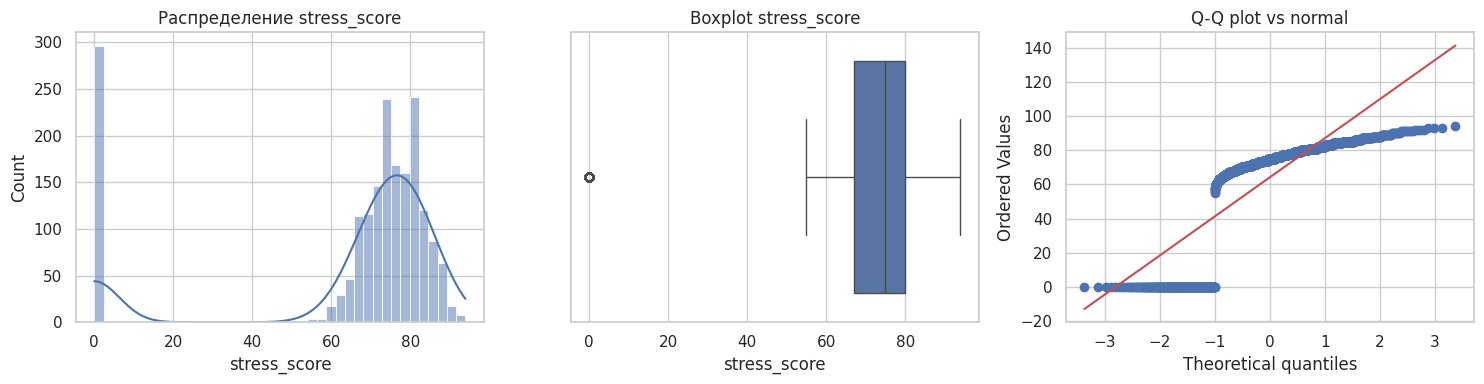

Skewness: -1.688
Kurtosis: 1.167


,stress_score
count,1876.000000
mean,64.181237
std,28.470995
min,0.000000
25%,67.000000
50%,75.000000
75%,80.000000
max,94.000000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_t[target_col], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Распределение stress_score')
sns.boxplot(x=df_t[target_col], ax=axes[1])
axes[1].set_title('Boxplot stress_score')
stats.probplot(df_t[target_col], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot vs normal')
plt.tight_layout()
plt.show()

print('Skewness:', round(df_t[target_col].skew(), 3))
print('Kurtosis:', round(df_t[target_col].kurt(), 3))
df_t[target_col].describe()

Таргет `stress_score` непрерывный, поэтому задача естественно формулируется как регрессия. По гистограмме, Q-Q plot и `skewness` видно, что распределение не идеально нормальное и имеет заметный перекос, поэтому при обучении модели стоит учитывать хвосты распределения и смотреть не только на среднюю ошибку, но и на устойчивость модели к нетипичным дням.

#### Константные бейзлайны

Считаю сразу - метрика без бейзлайна ни о чём не говорит. Это именно та планка, ниже которой модель становится бессмысленной.

In [8]:
y = df_t[target_col].values
mean_pred = np.full_like(y, y.mean(), dtype=float)
median_pred = np.full_like(y, np.median(y), dtype=float)

def mae(a, b):
    return float(np.mean(np.abs(a - b)))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

print(f'std(y)             = {y.std():.3f}')
print(f'MAE (mean pred)    = {mae(y, mean_pred):.3f}')
print(f'MAE (median pred)  = {mae(y, median_pred):.3f}')
print(f'RMSE (mean pred)   = {rmse(y, mean_pred):.3f}')
print('MAE (median) должен быть <= MAE (mean) — оптимальный константный предиктор по MAE это медиана.')

std(y)             = 28.463
MAE (mean pred)    = 20.431
MAE (median pred)  = 16.555
RMSE (mean pred)   = 28.463
MAE (median) должен быть <= MAE (mean) — оптимальный константный предиктор по MAE это медиана.


### Базовая статистика по числовым признакам

In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,7410,2021-09-13 05:17:32.307692288,2021-04-08 00:00:00,2021-07-05 00:00:00,2021-08-27 00:00:00,2021-11-29 00:00:00,2022-01-22 00:00:00,NaN
nightly_temperature,3359.0,33.77165,25.518333,33.305913,33.887166,34.34272,36.684793,0.905129
nremhr,2475.0,62.714134,0.0,57.4345,63.146,69.192,92.547,11.051482
rmssd,2475.0,40.021232,0.0,25.442,34.072,48.723,122.089,21.305442
spo2,1270.0,95.893228,89.4,95.2,95.9,96.7,100.0,1.114339
full_sleep_breathing_rate,2495.0,14.836954,0.0,13.2,15.0,17.0,29.8,3.774846
stress_score,1876.0,64.181237,0.0,67.0,75.0,80.0,94.0,28.470995
sleep_points_percentage,1876.0,0.653998,0.0,0.633333,0.733333,0.833333,1.0,0.303243
exertion_points_percentage,1876.0,0.632689,0.0,0.6,0.725,0.825,1.0,0.295897
responsiveness_points_percentage,1876.0,0.641791,0.0,0.633333,0.766667,0.833333,0.966667,0.293409


На что обращаю внимание:
- `steps` - максимум в районе нескольких десятков тысяч, что реалистично, но есть вероятность выбросов (человек забыл снять часы и стирал их в машинке). Ниже явно посчитаю сколько строк выпадают за IQR-фенсы.
- `sleep_duration` в миллисекундах (огромные числа), это неудобно, сконвертирую в часы для интерпретируемости.
- sleep ratios иногда > 1, что странно для доли - возможно там сумма не нормализована. Ниже проверю.
- `scl_avg` (electrodermal activity, средняя проводимость кожи) - прямой физиологический маркер стресса. Есть риск что она завязана на таргет, потому что Fitbit учитывает этот сигнал при расчёте stress_score (подробнее ниже в блоке про утечку).
- `nightly_temperature` ~34°C - скорее всего это не абсолютная температура кожи, а baseline-смещённое значение; в hw_2 уточню по доке LifeSnaps.

In [10]:
df['sleep_hours'] = df['sleep_duration'] / (1000 * 60 * 60)
df_t['sleep_hours'] = df_t['sleep_duration'] / (1000 * 60 * 60)
df['sleep_hours'].describe()

,sleep_hours
count,3551.000000
mean,7.500089
std,1.881692
min,1.000000
25%,6.550000
50%,7.633333
75%,8.683333
max,20.683333


Теперь читаемо, типичный сон 6-8 часов. Максимум ~20 часов явно подозрительный - это скорее всего артефакт (часы лежали на столе и думали что человек спит).

#### Быстрая проверка выбросов и sleep ratios

Не чищу данные в рамках hw_1, но хочу понимать масштаб проблемы.

In [11]:
def iqr_outliers(series, k=1.5):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    out = ((s < lo) | (s > hi)).sum()
    return {'lo': round(lo, 2), 'hi': round(hi, 2),
            'n_outliers': int(out), 'pct': round(100 * out / len(s), 2)}

for col in ['steps', 'sleep_hours', 'calories', 'resting_hr', 'rmssd']:
    if col in df.columns:
        print(col, iqr_outliers(df[col]))

print()
ratio_cols = ['sleep_deep_ratio', 'sleep_wake_ratio', 'sleep_light_ratio', 'sleep_rem_ratio']
for c in ratio_cols:
    if c in df.columns:
        s = df[c].dropna()
        print(f'{c}: max={s.max():.3f}, доля >1 = {(s > 1).mean()*100:.1f}%')

steps {'lo': np.float64(-5416.5), 'hi': np.float64(20923.5), 'n_outliers': 147, 'pct': np.float64(3.08)}
sleep_hours {'lo': np.float64(3.35), 'hi': np.float64(11.88), 'n_outliers': 148, 'pct': np.float64(4.17)}
calories {'lo': np.float64(304.03), 'hi': np.float64(3945.21), 'n_outliers': 124, 'pct': np.float64(1.86)}
resting_hr {'lo': np.float64(46.94), 'hi': np.float64(86.13), 'n_outliers': 29, 'pct': np.float64(0.66)}
rmssd {'lo': np.float64(-9.48), 'hi': np.float64(83.64), 'n_outliers': 138, 'pct': np.float64(5.58)}

sleep_deep_ratio: max=4.310, доля >1 = 47.6%
sleep_wake_ratio: max=3.708, доля >1 = 42.4%
sleep_light_ratio: max=3.034, доля >1 = 46.4%
sleep_rem_ratio: max=6.636, доля >1 = 47.8%


Видно, что `sleep_*_ratio` часто > 1 — значит это не доли от суммы, а скорее соотношения к какому-то baseline (надо свериться с докой Fitbit). В hw_2 либо переименую в `*_index` чтобы не путать себя, либо пересчитаю в честные доли от `minutesAsleep`. Выбросы в `steps`/`sleep_hours` есть, но их доля не катастрофическая - план: либо winsorize по квантилям, либо положиться на устойчивость бустинга.

### Корреляции с таргетом

Смотрю и Пирсона, и Спирмена - по scatter'ам видно что связи нелинейные, а Пирсон ловит только линейную часть. Корреляции считаю на `df_t` (строки с заполненным таргетом), а не на всём df.

In [12]:
num_df = df_t.select_dtypes(include=[np.number]).copy()

pearson = num_df.corr(method='pearson')[target_col].drop(target_col)
spearman = num_df.corr(method='spearman')[target_col].drop(target_col)

corr_tbl = pd.DataFrame({'pearson': pearson, 'spearman': spearman})
corr_tbl['abs_spearman'] = corr_tbl['spearman'].abs()
corr_tbl.sort_values('abs_spearman', ascending=False).head(20)

,pearson,spearman,abs_spearman
exertion_points_percentage,0.960909,0.820283,0.820283
sleep_points_percentage,0.953324,0.711262,0.711262
responsiveness_points_percentage,0.957153,0.671895,0.671895
max_goal,0.187898,0.340966,0.340966
min_goal,0.188642,0.338716,0.338716
scl_avg,0.267685,0.309452,0.309452
sleep_rem_ratio,0.090564,0.284543,0.284543
steps,0.110613,0.250251,0.250251
distance,0.098955,0.248673,0.248673
lightly_active_minutes,0.198886,0.231190,0.231190


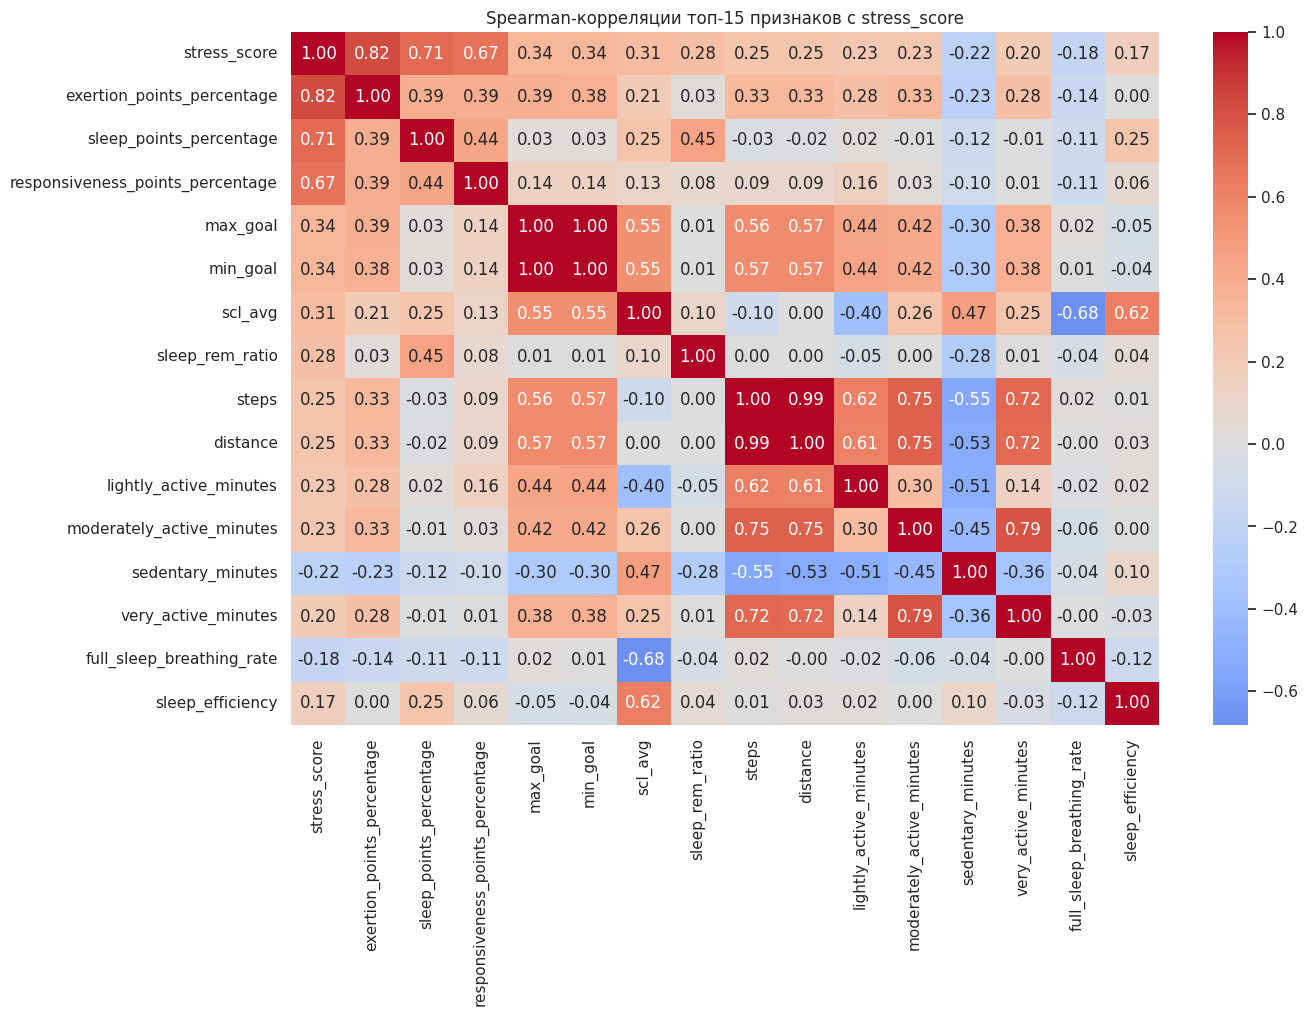

In [13]:
top = corr_tbl['abs_spearman'].sort_values(ascending=False).head(15).index.tolist()
plt.figure(figsize=(14, 9))
sns.heatmap(num_df[[target_col] + top].corr(method='spearman'),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Spearman-корреляции топ-15 признаков с stress_score')
plt.show()

### Про утечку признаков (важно)

По первым корреляциям видно, что больше всего скоррелированы компоненты, которые и входят в формулу stress_score у Fitbit:
- `sleep_points_percentage`
- `exertion_points_percentage`
- `responsiveness_points_percentage`

Это по сути части таргета - Fitbit складывает эти три sub-score и получает итоговый stress_score. Если их оставить, модель выучит формулу Fitbit, а не настоящие физиологические зависимости, и R² уйдёт в район 1. Эти три колонки я однозначно убираю в hw_2.

Серая зона - признаки, которые входят в расчёт stress_score не напрямую, а через sub-score:
- `scl_avg` (EDA) - используется в responsiveness-компоненте.
- `rmssd` (HRV), `resting_hr` - используются в sleep/responsiveness-компонентах.
- `sleep_efficiency`, `minutesAsleep` и т.п. - идут в sleep-компонент.

Формально это тоже часть формулы, но это реальная физиология, которую можно мерить и вне Fitbit. Поэтому план:
- Эксперимент A: без трёх sub-score, но со всей физиологией (честный продуктовый сценарий).
- Эксперимент B: дополнительно убираем `scl_avg` и смотрим насколько просаживается качество - это чтобы понять, не держится ли модель только на одном "почти-таргете".

После удаления sub-score самые сильные признаки по смыслу - HRV (rmssd), resting_hr, sleep_efficiency, scl_avg - посмотрим по факту в hw_2.

### Связь с некоторыми признаками детальнее

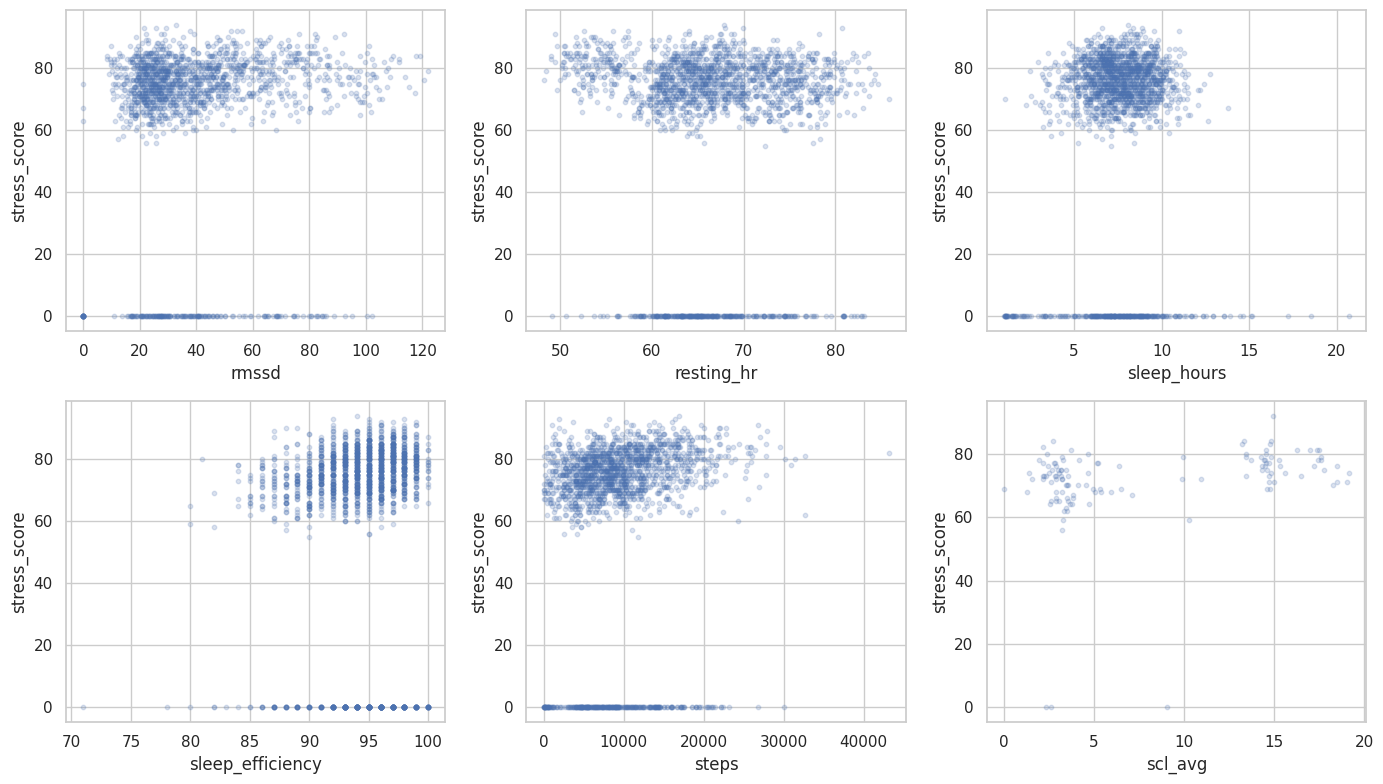

In [14]:
feats_to_plot = ['rmssd', 'resting_hr', 'sleep_hours', 'sleep_efficiency', 'steps', 'scl_avg']
feats_to_plot = [c for c in feats_to_plot if c in df_t.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, feats_to_plot):
    sub = df_t[[col, target_col]].dropna()
    ax.scatter(sub[col], sub[target_col], alpha=0.2, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
plt.tight_layout()
plt.show()

Видно что связи в основном не линейные, скорее облачные с трендом. Это подтверждается и тем, что Spearman-корреляции выше Пирсоновских по модулю для тех же признаков. Вывод: линейная модель будет работать средне, основная ставка - на градиентный бустинг.

### Категориальные признаки

In [15]:
cat_cols = ['gender', 'age', 'bmi', 'step_goal_label', 'badgeType']
for c in cat_cols:
    if c in df.columns:
        print(c, '|', df[c].value_counts(dropna=False).to_dict())
        print()

gender | {'MALE': 4178, 'FEMALE': 2862, nan: 370}

age | {'<30': 3642, '>=30': 3154, nan: 614}

bmi | {'24.0': 915, '20.0': 881, '21.0': 719, '22.0': 674, '<19': 663, nan: 614, '23.0': 505, '>=30': 476, '19.0': 405, '26.0': 348, '29.0': 302, '>=25': 294, '27.0': 251, '28.0': 183, '25.0': 180}

step_goal_label | {nan: 5495, '5000-7999': 602, '8000-9999': 362, '2000-4999': 310, 'No Goal': 247, '10000-14999': 200, 'Less than 2000': 139, '15000-19999': 44, '20000-24999': 10, 'More than 25000': 1}

badgeType | {nan: 6895, "['LIFETIME_DISTANCE']": 128, "['DAILY_STEPS']": 111, "['DAILY_FLOORS', 'DAILY_STEPS']": 83, "['LIFETIME_FLOORS']": 77, "['DAILY_FLOORS']": 75, "['LIFETIME_DISTANCE', 'LIFETIME_FLOORS']": 14, "['DAILY_STEPS', 'LIFETIME_FLOORS']": 7, "['LIFETIME_DISTANCE', 'DAILY_FLOORS', 'DAILY_STEPS']": 4, "['LIFETIME_WEIGHT_GOAL_SETUP']": 4, "['DAILY_FLOORS', 'DAILY_STEPS', 'LIFETIME_FLOORS']": 3, "['DAILY_FLOORS', 'LIFETIME_FLOORS']": 3, "['LIFETIME_DISTANCE', 'DAILY_STEPS']": 2, "['LIF

`activityType` и `badgeType` - это строки, содержащие python-списки. Распарсю и посмотрю распределение отдельных тегов, чтобы в hw_2 нормально их one-hot'нуть.

In [16]:
def safe_parse(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

for c in ['activityType', 'badgeType']:
    if c in df.columns:
        exploded = df[c].apply(safe_parse).explode()
        print(f'--- {c} ---')
        print(exploded.value_counts(dropna=True).head(15))
        print()

--- activityType ---
activityType
Walk                1696
Bike                 169
Workout              166
Sport                133
Aerobic Workout      119
Run                  118
Swim                  61
Yoga/Pilates          46
Circuit Training      37
Weights               37
Treadmill             24
Elliptical            14
Hike                  11
Martial Arts           6
Interval Workout       4
Name: count, dtype: int64

--- badgeType ---
badgeType
DAILY_STEPS                   212
DAILY_FLOORS                  171
LIFETIME_DISTANCE             151
LIFETIME_FLOORS               106
LIFETIME_WEIGHT_GOAL_SETUP      4
GOAL_BASED_WEIGHT_LOSS          1
Name: count, dtype: int64



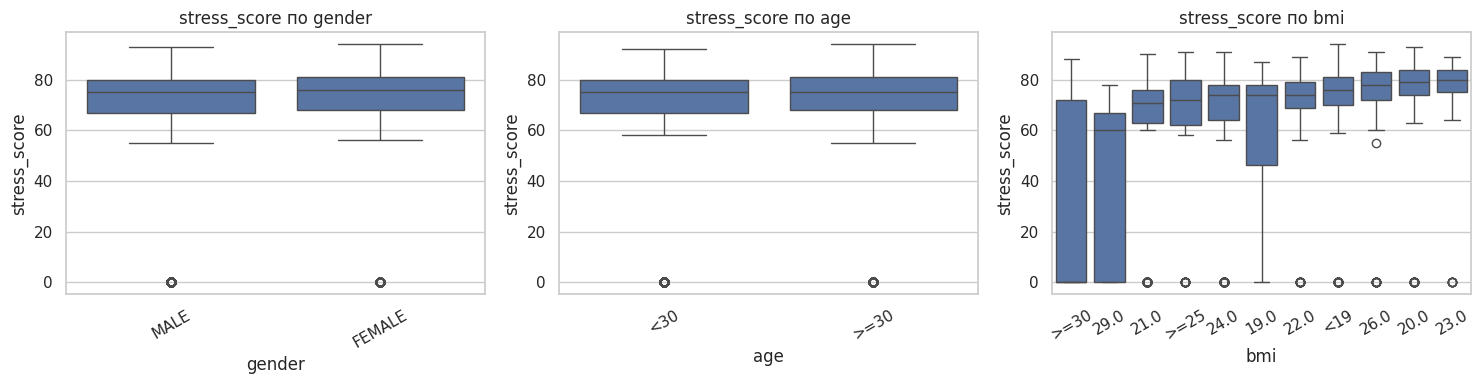

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, ['gender', 'age', 'bmi']):
    if c in df_t.columns:
        sub = df_t[[c, target_col]].dropna()
        order = sub.groupby(c)[target_col].median().sort_values().index
        sns.boxplot(data=sub, x=c, y=target_col, order=order, ax=ax)
        ax.set_title(f'stress_score по {c}')
        ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Категориальных немного, уровни понятные. Возраст и BMI уже забинены самим датасетом (например `<30`, `<19`). Для линейных моделей сделаю One-Hot Encoding, для бустинга можно скормить как есть (CatBoost сам умеет).

### SEMA (настроение и локация)

Это бинарные фичи - был ли соответствующий тег в самоотчёте за день. Отдельно интересно `TENSE/ANXIOUS` - это субъективная оценка стресса самим пользователем.

**Важно про шкалу Fitbit:** по имеющейся интерпретации `stress_score` больший балл соответствует более спокойному состоянию. Поэтому для SEMA-признаков интересно проверить, совпадает ли направление различий с интуицией. Ниже смотрю это не по ожиданиям, а по фактическим средним значениям в данных.

In [18]:
mood_cols = ['ALERT', 'HAPPY', 'NEUTRAL', 'RESTED/RELAXED', 'SAD', 'TENSE/ANXIOUS', 'TIRED']
mood_cols = [c for c in mood_cols if c in df_t.columns]

mood_stats = []
for c in mood_cols:
    sub = df_t[[c, target_col]].dropna()
    if sub[c].dtype == bool or set(sub[c].unique()).issubset({0, 1, True, False}):
        g = sub.groupby(c)[target_col].mean()
        n_yes = int(sub[c].sum())
        n_no = int((sub[c] == 0).sum())
        yes = sub.loc[sub[c] == 1, target_col]
        no = sub.loc[sub[c] == 0, target_col]
        pval = stats.ttest_ind(yes, no, equal_var=False).pvalue if len(yes) > 1 and len(no) > 1 else np.nan
        mood_stats.append({
            'mood': c,
            'mean_stress_no': round(g.get(False, g.get(0, np.nan)), 2),
            'mean_stress_yes': round(g.get(True, g.get(1, np.nan)), 2),
            'n_yes': n_yes, 'n_no': n_no,
            'p_value': round(pval, 4) if not np.isnan(pval) else np.nan,
        })
pd.DataFrame(mood_stats)

,mood,mean_stress_no,mean_stress_yes,n_yes,n_no,p_value
0,ALERT,67.26,64.47,160,881,0.2388
1,HAPPY,65.63,70.09,280,761,0.0117
2,NEUTRAL,65.55,70.27,283,758,0.0062
3,RESTED/RELAXED,68.06,64.58,368,673,0.0479
4,SAD,66.41,72.04,78,963,0.0345
5,TENSE/ANXIOUS,65.88,69.58,267,774,0.0307
6,TIRED,67.71,65.50,414,627,0.1890


По SEMA-признакам сигнал есть, но он не везде совпадает с интуитивным ожиданием. Для части тегов средний `stress_score` в группе `yes` отличается от группы `no`, однако направление эффекта нужно интерпретировать осторожно: это может быть связано с особенностями шкалы Fitbit, небольшим числом наблюдений по отдельным тегам и тем, что данные панельные (несколько дней на одного пользователя).

Но `n_yes` маленькие (78-414), поэтому добавил t-test Уэлча - по p-value видно, какие различия статзначимы, а какие могут быть просто шумом. Не стоит опираться на эти фичи как на сильные, и тем более делать из них единственные факторы.

Вопрос: оставлять ли SEMA признаки в модели? Плюс - они несут сигнал о субъективном самочувствии, которого нет в физиологии. Минус - они очень разреженные (мало заполненных дней), и в проде их может не быть. Решу в hw_2, скорее всего сделаю два эксперимента.

### Панельная структура данных

Важный момент - на каждого пользователя несколько десятков/сотен наблюдений. Если при train/test сплите просто случайно разбить строки, один и тот же человек попадёт и туда и туда, модель фактически выучит его индивидуальные паттерны и тест оценит оптимистично. По-хорошему надо делать split по пользователям (GroupKFold/GroupShuffleSplit с группировкой по `id`).

Также продуктовый сценарий "предсказать сегодняшний стресс по прошлым данным" содержит и временной аспект - в идеале делать Group + Time split (обучаемся на одних пользователях и на прошлом, валидируемся на других и/или на более позднем периоде). В hw_2 начну с GroupKFold, а временной сплит добавлю как дополнительный sanity-check.

In [19]:
per_user = df.groupby('id').agg(
    n_days=('date', 'count'),
    mean_stress=(target_col, 'mean'),
    std_stress=(target_col, 'std')
).sort_values('n_days', ascending=False)
per_user.head(10)

,n_days,mean_stress,std_stress
id,,,
621e367e67b776a24087d75d,244,NaN,NaN
621e346f67b776a24081744f,244,60.562500,23.612930
621e301e67b776a240608a72,244,38.660714,37.878887
621e2f1b67b776a240b3d87c,236,69.289474,12.813343
621e342e67b776a2404ce460,223,36.918919,34.745406
621e2f9167b776a240011ccb,187,75.193182,12.918718
621e32d967b776a240627414,162,39.117647,38.281657
621e34ca67b776a240be3b69,144,52.333333,31.060310
621e2efa67b776a2409dd1c3,137,NaN,NaN


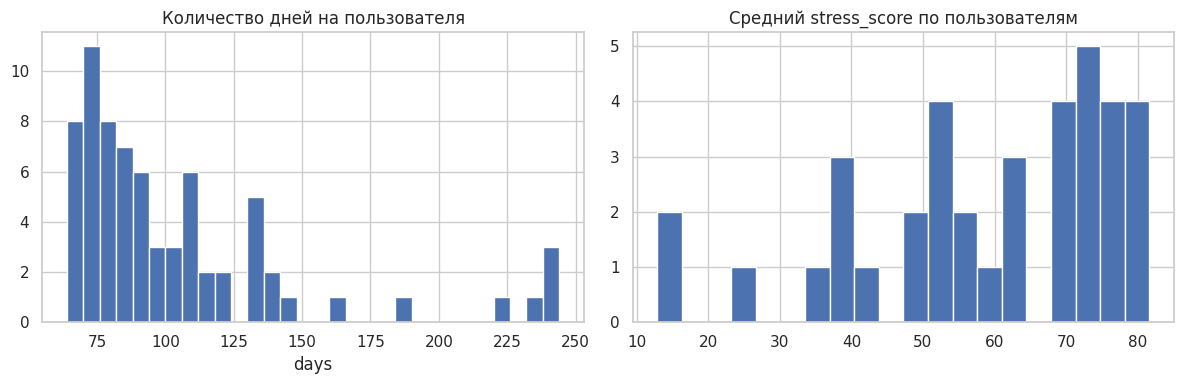

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
per_user['n_days'].hist(bins=30, ax=axes[0])
axes[0].set_title('Количество дней на пользователя')
axes[0].set_xlabel('days')
per_user['mean_stress'].hist(bins=20, ax=axes[1])
axes[1].set_title('Средний stress_score по пользователям')
plt.tight_layout()
plt.show()

Средние по пользователям довольно заметно разнятся - это подтверждает что split по группам важен. Плюс на это можно добавить user-level фичи (например средний ЧСС покоя по пользователю), хотя это уже будет в hw_2.

### Временные эффекты

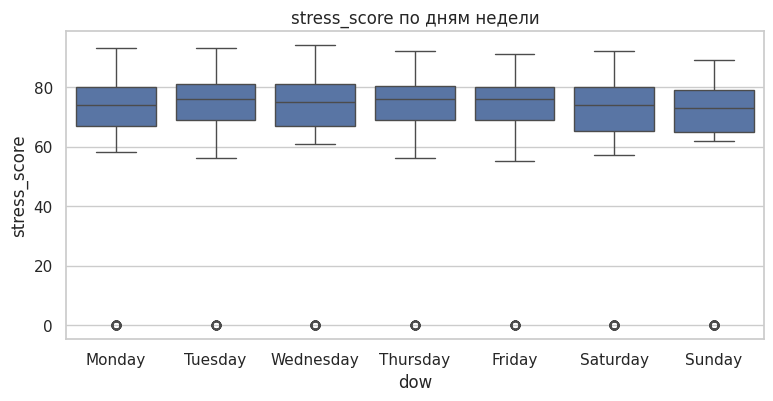

In [21]:
df_t['dow'] = df_t['date'].dt.day_name()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(9, 4))
sns.boxplot(data=df_t, x='dow', y=target_col, order=order)
plt.title('stress_score по дням недели')
plt.show()

Если виден заметный разброс по дням недели, имеет смысл добавить `dayofweek` / `is_weekend` как фичи. Похоже на выходных стресс чуть меньше, но разница не гигантская.

## Выводы по EDA

1. Таргет `stress_score` задан напрямую и является непрерывной числовой величиной, поэтому задача формулируется как регрессия. При этом распределение таргета имеет заметный перекос, что стоит учитывать при валидации и интерпретации ошибок модели.
2. Посчитаны константные бейзлайны: MAE медианного предсказания - нижняя планка, с которой сравниваю любую модель в hw_2.
3. Пропусков много, особенно в SEMA и части физиологии. На hw_2 придётся выбирать стратегию: или модели устойчивые к NaN (LightGBM/CatBoost), или импутация с флагами.
4. Есть прямая утечка через `sleep_points_percentage`, `exertion_points_percentage`, `responsiveness_points_percentage` - это компоненты формулы Fitbit stress_score, их выкидываю в hw_2.
5. Серая зона утечки: `scl_avg`, `rmssd`, `resting_hr`, `sleep_efficiency` и другие сигналы, которые Fitbit учитывает в sub-score. Это реальная физиология, оставляю, но сделаю abl-эксперимент без `scl_avg`.
6. Связи нелинейные (Spearman > Pearson по модулю на тех же признаках), линейная модель - только как бейзлайн, основная ставка на градиентный бустинг.
7. Данные панельные, сплит обязательно по группам (GroupKFold по `id`), плюс дополнительно сделаю time-aware split как sanity-check.
8. Технические фиксы: `sleep_duration` → часы, `sleep_*_ratio` разобраться (бывает > 1), `activityType`/`badgeType` распарсить из строки-списка в нормальные флаги, `mindfulness_session` привести к числовому типу.
9. Выбросы (steps, sleep_hours) заметные по доле, но не катастрофические - план: winsorize по квантилям либо положиться на устойчивость бустинга.
10. Категориальные признаки с малым числом уровней, OHE для линейных, встроенная обработка для бустинга.
11. SEMA даёт дополнительный сигнал, но интерпретировать его нужно осторожно: выборки небольшие, а направление эффекта не везде однозначно.
12. Имеет смысл добавить простые временные фичи (день недели, выходной), а также user-level агрегаты.